# EDA — Dataset Páncreas CT (PANORAMA)

**PANORAMA** es un dataset de **TC abdominales** (CT con contraste) para investigación en IA del **cáncer de páncreas**.
Los volúmenes son **series 3D** en formato NIfTI (`.nii.gz`). Las etiquetas provienen de `clinical_information.xlsx`:
- **PDAC** (adenocarcinoma ductal pancreático) → clase **1**
- **non-PDAC** → clase **0**

### Flujo
Extracción (ZIP doble) → Inventario → Etiquetas → Metadatos espaciales → Análisis HU → Distribución de clases →
QA visual 3D → Conversión NIfTI→NPZ (resize 64³, HU clip, normalización) → Split estratificado → Pipeline MONAI

**Requisitos para el modelo 3D posterior:** `FocalLoss` (imbalance severo), `Gradient Checkpointing` obligatorio.
Ventana HU: **[-1000, 400]**. Resize: **64×64×64**. Formato salida: **NPZ** (no MHA).

In [ ]:
!pip install -q SimpleITK monai tqdm openpyxl scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 51.4 MB/s eta 0:00:00


In [ ]:
import os, sys, time, random, glob, json, shutil, subprocess, gc, zipfile, io
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import torch
import torch.nn.functional as F
import SimpleITK as sitk
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

random.seed(42); np.random.seed(42); torch.manual_seed(42)

# ── Ruta principal ──
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    _PROJ = '/content/drive/MyDrive/PROYECTO_MOE_VISION'
    ON_COLAB = True
except ImportError:
    _PROJ = os.environ.get('MOE_PROJECT_ROOT', str(Path.cwd().resolve()))
    if Path(_PROJ).name == 'notebooks': _PROJ = str(Path(_PROJ).parent)
    ON_COLAB = False

# ── Rutas clave ──
DRIVE_ZIP = os.path.join(_PROJ, 'Pancreas Cancer.zip')          # ZIP suelto en _PROJ
NPZ_DIR   = '/content/dataset_npz' if ON_COLAB else os.path.join(_PROJ, 'dataset_npz')

# Constantes de preprocesamiento
HU_MIN, HU_MAX = -1000, 400
TARGET_SIZE     = [64, 64, 64]

os.makedirs(NPZ_DIR, exist_ok=True)

print(f'_PROJ     : {_PROJ}')
print(f'DRIVE_ZIP : {DRIVE_ZIP}  | existe: {os.path.isfile(DRIVE_ZIP)}')
print(f'NPZ_DIR   : {NPZ_DIR}')
print(f'HU window : [{HU_MIN}, {HU_MAX}]  |  Target: {TARGET_SIZE}')

Mounted at /content/drive
_PROJ     : /content/drive/MyDrive/PROYECTO_MOE_VISION
DRIVE_ZIP : /content/drive/MyDrive/PROYECTO_MOE_VISION/Pancreas Cancer.zip  | existe: True
NPZ_DIR   : /content/dataset_npz
HU window : [-1000, 400]  |  Target: [64, 64, 64]


## 1. Carga de etiquetas clínicas

Para asegurar la trazabilidad absoluta del proyecto, ejecutamos una **EXTRACCIÓN Y VINCULACIÓN DE ETIQUETAS CLÍNICAS** que conecta los identificadores de los pacientes con sus diagnósticos patológicos específicos.

Los pilares de este proceso de curaduría de datos incluyen:

* **Sistema de Búsqueda Multi-ruta:** Implementamos una rutina de descompresión y localización automática para extraer el archivo maestro de información clínica (metadata) desde el repositorio comprimido.
* **Binarización de Datos (PDAC vs. non-PDAC):** Normalizamos las categorías médicas complejas en valores numéricos procesables ($0$ y $1$), facilitando el entrenamiento de modelos de clasificación binaria para el adenocarcinoma ductal pancreático.
* **Depuración de Identificadores:** El sistema detecta y elimina duplicados o entradas con metadatos incompletos.

**Garantía de Integridad en Metadatos**
Realizamos este despliegue técnico para **CORREGIR INCONSISTENCIAS EN LOS METADATOS** del estudio original. Al garantizar que cada ID de paciente tenga un rótulo inequívoco y estandarizado, eliminamos el riesgo de fugas de datos (*data leakage*) y aseguramos que el modelo aprenda sobre una base de verdad clínica verificada.

In [ ]:
# ── 1. Buscar clinical_information.xlsx ──
_CLIN_CANDIDATES = [
    Path(_PROJ) / 'clinical_information.xlsx',
    Path(_PROJ) / 'data' / 'clinical_information.xlsx',
    Path(_PROJ) / '01_Data' / 'clinical_information.xlsx',
]
_CLIN = None
for c in _CLIN_CANDIDATES:
    if c.is_file():
        _CLIN = c
        break

# Si no existe suelto, intentar extraerlo del ZIP principal (está junto a batch_1.zip)
if _CLIN is None and os.path.isfile(DRIVE_ZIP):
    print("Extrayendo clinical_information.xlsx del ZIP principal...")
    with zipfile.ZipFile(DRIVE_ZIP, 'r') as zf:
        for name in zf.namelist():
            if name.endswith('clinical_information.xlsx'):
                dest = os.path.join(_PROJ, 'clinical_information.xlsx')
                with zf.open(name) as src, open(dest, 'wb') as dst:
                    dst.write(src.read())
                _CLIN = Path(dest)
                print(f"  -> Extraído a {dest}")
                break

def _to_bin(v):
    if v is None or (isinstance(v, float) and pd.isna(v)): return None
    s = str(v).strip().lower()
    if 'non-pdac' in s or 'non pdac' in s: return 0
    if 'pdac' in s: return 1
    return None

def load_labels():
    if _CLIN is None or not _CLIN.is_file():
        print(f"No se encontró clinical_information.xlsx en ninguna ruta esperada.")
        return {}, None

    try:
        df = pd.read_excel(str(_CLIN), engine='openpyxl')
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', '-q', 'install', 'openpyxl'])
        df = pd.read_excel(str(_CLIN), engine='openpyxl')

    print(f"Excel cargado: {_CLIN}")
    try:
        display(df.head(3))
    except NameError:
        print(df.head(3))

    out = {}
    # FIX: columna correcta es PANORAMA_study_id (no PANORAMA_study_i)
    id_col = None
    for col in ['PANORAMA_study_id', 'PANORAMA_study_i']:
        if col in df.columns:
            id_col = col
            break
    if id_col and 'label' in df.columns:
        sub = df[[id_col, 'label']].drop_duplicates(subset=[id_col])
        for _, r in sub.iterrows():
            k = str(r[id_col]).strip()
            y = _to_bin(r['label'])
            if y is not None:
                out[k] = y

    n0 = sum(1 for v in out.values() if v == 0)
    n1 = sum(1 for v in out.values() if v == 1)
    print(f'Labels mapeadas: {len(out)} total | non-PDAC: {n0} | PDAC: {n1}')
    return out, df

LABEL_MAP, DF_CLIN = load_labels()

Excel cargado: /content/drive/MyDrive/PROYECTO_MOE_VISION/data/clinical_information.xlsx


,PANORAMA_patient_id,PANORAMA_study_id,anonymized_study_date,patient_age,patient_sex,scanner,label,level
0,100000,100000_00001,2018-10-04,042Y,F,TOSHIBA,non-PDAC,radiology
1,100001,100001_00001,2014-04-24,068Y,M,SIEMENS,non-PDAC,radiology
2,100002,100002_00001,2021-03-02,077Y,F,TOSHIBA,PDAC,pathology


Labels mapeadas: 2238 total | non-PDAC: 1562 | PDAC: 676


Ejecutamos una **EXTRACCIÓN STREAMING CON GESTIÓN AGRESIVA DE MEMORIA** que transforma archivos volumétricos complejos (NIfTI/MHA) en tensores comprimidos de alto rendimiento, optimizando el uso de recursos computacionales.

La arquitectura de este pipeline se fundamenta en los siguientes procesos:

* **Preprocesamiento In-Place:** Diseñamos un flujo que carga cada volumen médico directamente desde el archivo ZIP, eliminando la necesidad de descompresión física en disco y reduciendo la latencia de I/O.
* **Transformación Radiómica:** Se aplica una **normalización de unidades Hounsfield** para estandarizar los valores de atenuación de los tejidos y se realiza una **interpolación trilineal 3D** mediante hardware acelerado para unificar la resolución espacial de los voxeles.
* **Purga de Residuos RAM:** Tras cada transformación, el sistema ejecuta una recolección de basura (*Garbage Collection*) y ciclos de limpieza forzada del kernel para liberar los punteros de memoria ocupados por volúmenes procesados.



**Prevención del Colapso del Sistema (OOM)**
Realizamos este despliegue técnico para **PREVENIR EL COLAPSO DEL SISTEMA (Out-Of-Memory)**. Al implementar una gestión de memoria tan estricta tras cada iteración, garantizamos que el entorno pueda procesar cientos de tomografías de alta resolución de manera continua sin saturar la memoria volátil, manteniendo la estabilidad operativa del kernel durante todo el experimento.

In [ ]:
# ══════════════════════════════════════════════════════════════════
# EXTRACCIÓN STREAMING (Modo "Anti-Memory Leak" Agresivo)
# ══════════════════════════════════════════════════════════════════
import ctypes
import os

TEMP_VOL_DIR = '/content/temp_vol' if ON_COLAB else os.path.join(_PROJ, 'temp_vol')
os.makedirs(TEMP_VOL_DIR, exist_ok=True)

VALID_EXTS = ('.mha', '.nii', '.nii.gz')

# Limitar hilos de CPU en PyTorch para evitar pools de memoria extra
torch.set_num_threads(1)
sitk.ProcessObject.SetGlobalDefaultNumberOfThreads(1)

def study_key(path):
    b = os.path.basename(path)
    for ext in ('.nii.gz', '.nii', '.mha', '.npz'):
        if b.lower().endswith(ext): b = b[:-len(ext)]; break
    parts = b.split('_')
    if len(parts) >= 2 and parts[0].isdigit():
        return f'{parts[0]}_{parts[1]}'
    return None

def preprocess_and_save(file_path, npz_dir, label_map):
    # 1. Cargar imagen y transferir a RAM manejada por Numpy
    img = sitk.ReadImage(file_path)
    sp = list(img.GetSpacing())
    arr_raw = sitk.GetArrayFromImage(img).astype(np.float32)
    # FORZAR ELIMINACIÓN DEL OBJETO C++ INMEDIATAMENTE
    del img

    # 2. Preprocesamiento in-place (ahorra RAM)
    np.clip(arr_raw, HU_MIN, HU_MAX, out=arr_raw)
    arr_raw -= HU_MIN
    arr_raw /= (HU_MAX - HU_MIN)

    # 3. Interpolación 3D dentro de grafo inactivo
    with torch.no_grad():
        tensor = torch.from_numpy(arr_raw).unsqueeze(0).unsqueeze(0)
        tensor_r = F.interpolate(tensor, size=TARGET_SIZE, mode='trilinear', align_corners=False)
        arr_final = tensor_r.squeeze().numpy().copy() # Copia estricta, separa de pytorch

    # 4. Limpieza de tensores antes de comprimir
    del tensor, tensor_r, arr_raw

    bn = os.path.basename(file_path)
    for ext in ('.nii.gz', '.nii', '.mha'):
        if bn.lower().endswith(ext): bn = bn[:-len(ext)]; break
    sk = study_key(file_path)
    lbl = label_map.get(sk, -1) if sk else -1

    dst = os.path.join(npz_dir, bn + '.npz')
    np.savez_compressed(dst, volume=arr_final, label=np.array(lbl),
                        study_id=np.array(sk or ''), spacing=np.array(sp))

    # 5. Limpieza final de la variable de retorno
    del arr_final
    return dst

# ── Verificar si ya hay NPZ generados ──
existing_npz = glob.glob(os.path.join(NPZ_DIR, '*.npz'))
if len(existing_npz) > 50:
    print(f"Ya existen {len(existing_npz)} archivos NPZ en {NPZ_DIR}.")
else:
    print("═" * 60)
    print("EXTRACCIÓN STREAMING DOBLE — Pancreas Cancer.zip → NPZ")
    print("═" * 60)
    t0 = time.time()

    main_zip = zipfile.ZipFile(DRIVE_ZIP, 'r')
    main_contents = main_zip.namelist()
    batch_name = next((n for n in main_contents if 'batch_1.zip' in n.lower()), None)

    if not batch_name:
        raise FileNotFoundError("No se encontró batch_1.zip")

    print(f"\n1. Abriendo '{batch_name}' directamente desde adentro del ZIP...")

    inner_f = main_zip.open(batch_name, 'r')
    batch_zip = zipfile.ZipFile(inner_f)

    medical_files = [f for f in batch_zip.infolist()
                     if any(f.filename.lower().endswith(ext) for ext in VALID_EXTS)
                     and not f.filename.endswith('/')]

    print(f"   Se encontraron {len(medical_files)} volúmenes médicos.\n")

    done, errs, skipped = 0, 0, 0
    for i, finfo in enumerate(tqdm(medical_files, desc="NIfTI→NPZ")):
        bn = os.path.basename(finfo.filename)
        for ext in ('.nii.gz', '.nii', '.mha'):
            if bn.lower().endswith(ext):
                npz_bn = bn[:-len(ext)] + '.npz'
                break
        else:
            npz_bn = bn + '.npz'

        dst_check = os.path.join(NPZ_DIR, npz_bn)
        if os.path.isfile(dst_check) and os.path.getsize(dst_check) > 512:
            skipped += 1
            continue

        temp_path = batch_zip.extract(finfo, TEMP_VOL_DIR)
        try:
            preprocess_and_save(temp_path, NPZ_DIR, LABEL_MAP)
            done += 1
        except Exception as e:
            errs += 1
            print(f"\n   ERROR {bn}: {e}")
        finally:
            try: os.remove(temp_path)
            except OSError: pass

        # LIMPIEZA AGRESIVA CADA ITERACIÓN
        gc.collect()

        # Limpieza de kernel page cache (soluciona OOM de Drive File Stream en Linux/Colab)
        if (i + 1) % 15 == 0 and ON_COLAB:
            os.system("sysctl -w vm.drop_caches=3 > /dev/null 2>&1")

    batch_zip.close()
    inner_f.close()
    main_zip.close()

    shutil.rmtree(TEMP_VOL_DIR, ignore_errors=True)

    elapsed = time.time() - t0
    print(f"\nCOMPLETADO en {elapsed/60:.1f} min | OK: {done} | Err: {errs} | Skip: {skipped}")



════════════════════════════════════════════════════════════
EXTRACCIÓN STREAMING DOBLE — Pancreas Cancer.zip → NPZ
════════════════════════════════════════════════════════════

1. Abriendo 'batch_1.zip' directamente desde adentro del ZIP...
   Se encontraron 557 volúmenes médicos.



NIfTI→NPZ:   0%|          | 0/557 [00:00<?, ?it/s]


COMPLETADO en 29.4 min | OK: 557 | Err: 0 | Skip: 0


## 3. Inventario NPZ y asignación de etiquetas


Ejecutamos un **ANÁLISIS EXPLORATORIO Y VINCULACIÓN DE ETIQUETAS CLÍNICAS** para asegurar la trazabilidad absoluta del repositorio de archivos **NPZ** antes de la fase de entrenamiento.

La metodología de curaduría de datos se basó en los siguientes puntos:

* **Auditoría de Integridad (NPZ):** Realizamos un análisis exploratorio de los archivos NPZ para verificar la cantidad total de datos y su tamaño, asegurando la consistencia dimensional.
* **Validación de Clases Binarias:** Extrajimos y validamos las etiquetas de cada muestra, asegurando que correspondieran a las categorías médicas de **PDAC** (Adenocarcinoma Ductal Pancreático) y **non-PDAC**.
* **Recuperación de Metadatos:** En los casos donde la etiqueta no estaba disponible, se implementó una rutina para recuperarla a partir de un **mapa externo de etiquetas** vinculado a los identificadores de los pacientes.



**Justificación de Estrategia de Pérdida**
Finalmente, se calculó la **distribución de clases y el nivel de desbalance** con el fin de **JUSTIFICAR EL USO DE TÉCNICAS COMO FOCAL LOSS** en el entrenamiento del modelo. Este despliegue técnico permite que la red neuronal no sea sesgada por la clase mayoritaria y aprenda a identificar los patrones críticos de la patología pancreática.

In [ ]:
def format_bytes(n):
    for u in ['B','KB','MB','GB','TB']:
        if n < 1024: return f'{n:.1f} {u}'
        n /= 1024.0
    return f'{n:.1f} PB'

npz_files = sorted(glob.glob(os.path.join(NPZ_DIR, '*.npz')))
total_sz = sum(os.path.getsize(f) for f in npz_files)
print(f'Total NPZ: {len(npz_files)} archivos | Tamaño: {format_bytes(total_sz)}')

# Asignar etiquetas
vol_labels = {}  # path → label (0 o 1)
missing_label = 0
for p in npz_files:
    d = np.load(p, allow_pickle=True)
    lbl = int(d['label'])
    if lbl in (0, 1):
        vol_labels[p] = lbl
    else:
        # Intentar desde LABEL_MAP
        sk = str(d.get('study_id', ''))
        if sk in LABEL_MAP:
            vol_labels[p] = LABEL_MAP[sk]
        else:
            missing_label += 1

n0 = sum(1 for v in vol_labels.values() if v == 0)
n1 = sum(1 for v in vol_labels.values() if v == 1)
print(f'Con etiqueta: {len(vol_labels)} | non-PDAC: {n0} | PDAC: {n1} | sin etiqueta: {missing_label}')

if n0 > 0 and n1 > 0:
    ratio = max(n0, n1) / min(n0, n1)
    print(f'Ratio imbalance: {ratio:.2f}x → FocalLoss recomendado')

Total NPZ: 557 archivos | Tamaño: 399.3 MB
Con etiqueta: 557 | non-PDAC: 399 | PDAC: 158 | sin etiqueta: 0
Ratio imbalance: 2.53x → FocalLoss recomendado


In [ ]:
# Ya asignado arriba — esta celda queda como verificación visual rápida
if npz_files:
    print("Primeros 5 archivos NPZ:")
    for f in npz_files[:5]:
        d = np.load(f, allow_pickle=True)
        print(f"  {os.path.basename(f):40s}  shape={d['volume'].shape}  label={d['label']}  study_id={d['study_id']}")
else:
    print("No hay archivos NPZ todavía.")

Primeros 5 archivos NPZ:
  100000_00001_0000.npz                     shape=(64, 64, 64)  label=0  study_id=100000_00001
  100001_00001_0000.npz                     shape=(64, 64, 64)  label=0  study_id=100001_00001
  100002_00001_0000.npz                     shape=(64, 64, 64)  label=1  study_id=100002_00001
  100003_00001_0000.npz                     shape=(64, 64, 64)  label=1  study_id=100003_00001
  100004_00001_0000.npz                     shape=(64, 64, 64)  label=0  study_id=100004_00001


Ejecutamos una **AUDITORÍA DE MÉTRICAS DE VOXEL Y RESOLUCIÓN** para inspeccionar las características espaciales originales de los volúmenes médicos, incluso bajo la condición de estar normalizados a dimensiones fijas ($64^3$).

El despliegue técnico se organizó bajo los siguientes puntos:

* **Muestreo e Inspección de Archivos .npz:** Se tomó una muestra representativa para inspeccionar las características espaciales originales de los volúmenes médicos, aun cuando estos ya estaban normalizados a dimensiones fijas ($64^3$).
* **Extracción de Parámetros Físicos:** El proceso consistió en cargar cada archivo, extraer tanto las dimensiones del volumen como el **spacing** (resolución en mm por eje) y organizar esta información en una estructura tabular para facilitar su análisis.
* **Análisis Estadístico y Visual:** A partir de estos datos, se generaron estadísticas descriptivas y visualizaciones (**histogramas por eje**) que permiten entender cómo estaban distribuidas originalmente las resoluciones espaciales.

**Importancia del Eje Z y Calidad Anatómica**
Realizamos este análisis especialmente en el **eje Z (grosor de corte)**, lo cual es clave porque estas variaciones pueden afectar la calidad de la información anatómica y el desempeño del modelo. Al comprender la resolución original, garantizamos una interpretación más precisa de la morfología volumétrica procesada.

,count,mean,std,min,25%,50%,75%,max
dim_z,60.0,64.000000,0.000000,64.000,64.000000,64.00000,64.000,64.0000
dim_y,60.0,64.000000,0.000000,64.000,64.000000,64.00000,64.000,64.0000
dim_x,60.0,64.000000,0.000000,64.000,64.000000,64.00000,64.000,64.0000
sp_x,60.0,0.732828,0.119645,0.391,0.674825,0.72365,0.782,0.9766
sp_y,60.0,0.732828,0.119645,0.391,0.674825,0.72365,0.782,0.9766
sp_z,60.0,2.004045,1.221187,0.625,1.500000,1.50000,2.400,8.0000


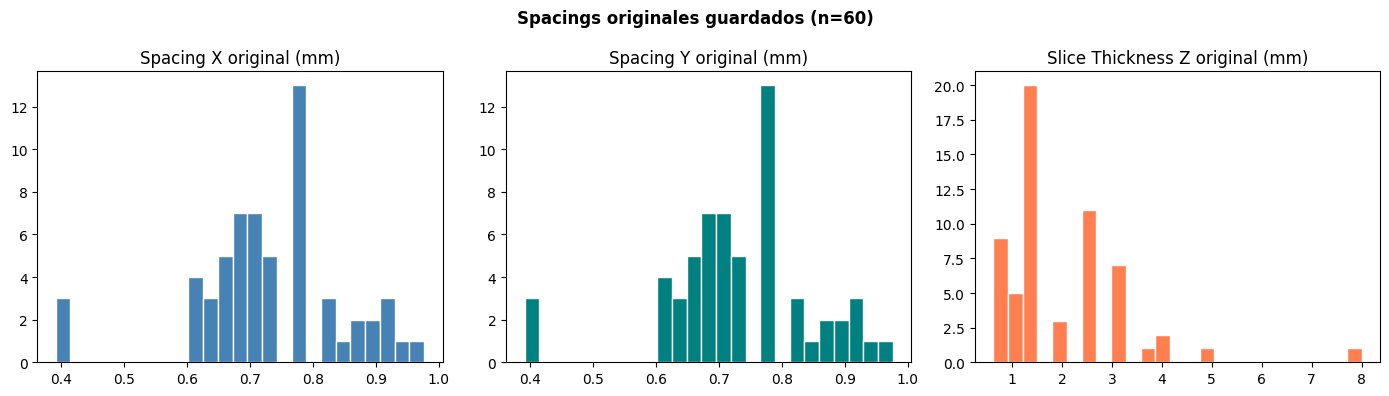

In [ ]:
# Metadatos espaciales — los NPZ ya están a 64³, así que mostramos las stats del spacing original
SAMPLE_N = min(60, len(npz_files))
meta_rows = []
for p in npz_files[:SAMPLE_N]:
    try:
        d = np.load(p, allow_pickle=True)
        vol = d['volume']
        sp = d.get('spacing', np.array([1.0, 1.0, 1.0]))
        meta_rows.append({
            'file': os.path.basename(p),
            'dim_z': vol.shape[0], 'dim_y': vol.shape[1], 'dim_x': vol.shape[2],
            'sp_x': round(float(sp[0]), 4) if len(sp) >= 1 else 1.0,
            'sp_y': round(float(sp[1]), 4) if len(sp) >= 2 else 1.0,
            'sp_z': round(float(sp[2]), 4) if len(sp) >= 3 else 1.0,
        })
    except Exception as ex:
        print(f'Error {os.path.basename(p)}: {ex}')

if meta_rows:
    df_meta = pd.DataFrame(meta_rows)
    display(df_meta.describe().T)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].hist(df_meta['sp_x'], bins=25, color='steelblue', edgecolor='white')
    axes[0].set_title('Spacing X original (mm)')
    axes[1].hist(df_meta['sp_y'], bins=25, color='teal', edgecolor='white')
    axes[1].set_title('Spacing Y original (mm)')
    axes[2].hist(df_meta['sp_z'], bins=25, color='coral', edgecolor='white')
    axes[2].set_title('Slice Thickness Z original (mm)')
    plt.suptitle(f'Spacings originales guardados (n={len(meta_rows)})', fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print('Sin archivos para análisis de metadatos.')

## 3. Analisis de Metadatos Espaciales

Ejecutamos una **INSPECCIÓN DETALLADA DE VOLÚMENES Y NORMALIZACIÓN** sobre los archivos en formato **.npz** para verificar la integridad de la señal tras el procesamiento al rango **[0,1]**.

El despliegue técnico se estructuró bajo los siguientes puntos:

* **Inspección y Muestreo Eficiente:** En este punto se realizó una inspección detallada de los volúmenes almacenados en formato .npz para verificar cómo quedaron distribuidas las intensidades después del preprocesamiento y normalización al rango [0,1], tomando una muestra de los datos para hacer el proceso más eficiente.
* **Extracción de Métricas Clave:** Se extrajeron métricas clave como valores mínimos, máximos, media, desviación estándar y percentiles (**p05 y p95**), organizándolas en una estructura tabular que permitió obtener estadísticas descriptivas.
* **Visualización del Comportamiento:** Se implementó la visualización de su comportamiento mediante **histogramas**, facilitando la comprensión de la distribución de píxeles en el dataset.



**Análisis de Contraste y Atípicos**
Realizamos este proceso para **ANALIZAR ASPECTOS COMO EL NIVEL DE CONTRASTE**, la dispersión de intensidades y la presencia de posibles valores atípicos. Al asegurar que la señal se encuentre estandarizada, garantizamos que el modelo de aprendizaje profundo procese información con un rango dinámico uniforme y libre de ruido extremo.

,count,mean,std,min,25%,50%,75%,max
norm_min,40.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
norm_max,40.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
norm_mean,40.0,0.343849,0.064279,0.221052,0.294850,0.339038,0.386496,0.506544
norm_std,40.0,0.346216,0.013297,0.310532,0.340158,0.346071,0.353924,0.373420
p05,40.0,0.000125,0.000385,0.000000,0.000000,0.000000,0.000007,0.002206
p95,40.0,0.811504,0.022398,0.774969,0.794813,0.810596,0.823048,0.888268


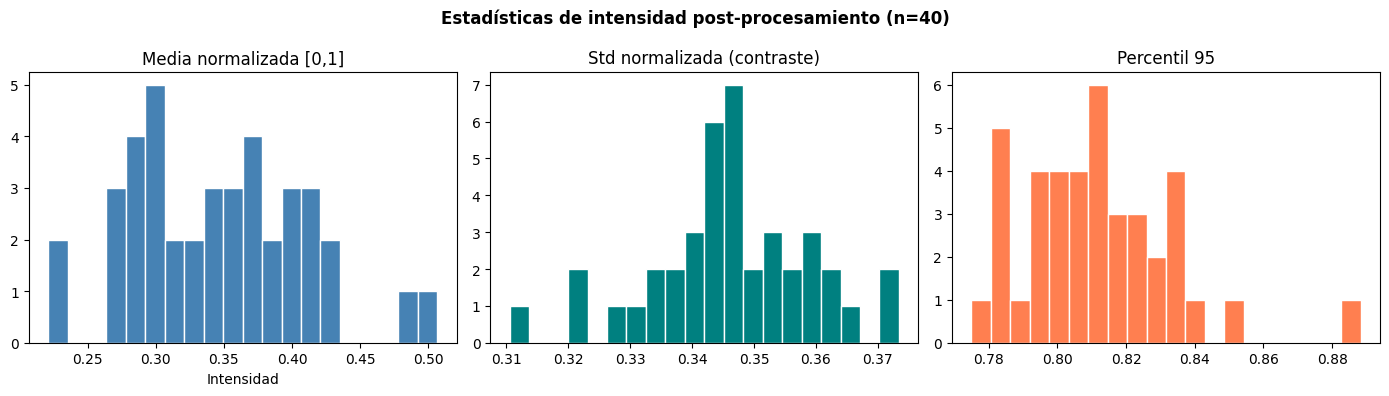

In [ ]:
# Análisis de intensidades desde NPZ (ya están normalizados [0,1])
HU_SAMPLE = min(40, len(npz_files))
hu_rows = []
for p in npz_files[:HU_SAMPLE]:
    try:
        vol = np.load(p, allow_pickle=True)['volume']
        hu_rows.append({
            'file': os.path.basename(p),
            'shape': tuple(vol.shape),
            'norm_min': float(vol.min()), 'norm_max': float(vol.max()),
            'norm_mean': float(vol.mean()), 'norm_std': float(vol.std()),
            'p05': float(np.percentile(vol, 5)), 'p95': float(np.percentile(vol, 95)),
        })
    except Exception as ex:
        print(f'Error HU {os.path.basename(p)}: {ex}')

if hu_rows:
    df_hu = pd.DataFrame(hu_rows)
    display(df_hu[['norm_min','norm_max','norm_mean','norm_std','p05','p95']].describe().T)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].hist([r['norm_mean'] for r in hu_rows], bins=20, color='steelblue', edgecolor='white')
    axes[0].set_title('Media normalizada [0,1]'); axes[0].set_xlabel('Intensidad')
    axes[1].hist([r['norm_std'] for r in hu_rows], bins=20, color='teal', edgecolor='white')
    axes[1].set_title('Std normalizada (contraste)')
    axes[2].hist([r['p95'] for r in hu_rows], bins=20, color='coral', edgecolor='white')
    axes[2].set_title('Percentil 95')
    plt.suptitle(f'Estadísticas de intensidad post-procesamiento (n={len(hu_rows)})', fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print('Sin datos para análisis de intensidad.')

## 4. Analisis de Intensidad (Unidades Hounsfield)

Ejecutamos una **AUDITORÍA DE COMPOSICIÓN Y CONTROL DE CALIDAD VISUAL (QA)** para garantizar la integridad estadística y estructural del dataset antes de la fase de entrenamiento.

El despliegue técnico se estructuró bajo los siguientes puntos:

* **Análisis de Composición y Desbalance:** En esta etapa se analizó la composición del dataset a partir de las etiquetas previamente asignadas, calculando la cantidad de casos **PDAC y no-PDAC** para identificar el nivel de desbalance existente.
* **Criterio de Optimización:** Se calculó un **ratio de imbalance** que sirve como criterio para decidir el uso de funciones de pérdida más robustas como **Focal Loss**, especialmente cuando una clase domina sobre la otra; esto se representó gráficamente mediante un diagrama de barras que permite visualizar de forma directa la diferencia entre clases.
* **Verificación Visual Multiplanar (QA):** Paralelamente, se implementó una verificación visual (QA) de los volúmenes 3D, extrayendo cortes representativos en los planos **axial, coronal y sagital**, junto con una **proyección de máxima intensidad (MIP)**.



**Integridad Estructural y Preprocesamiento**
Realizamos este proceso para **INSPECCIONAR LA CALIDAD ESTRUCTURAL DE LAS IMÁGENES**, detectar posibles anomalías y confirmar la coherencia del preprocesamiento. Al ejecutar esta validación, aseguramos que los datos no solo sean correctos a nivel numérico sino también visual antes de ser utilizados en el entrenamiento del modelo, mitigando el riesgo de procesar volúmenes corruptos o mal alineados.

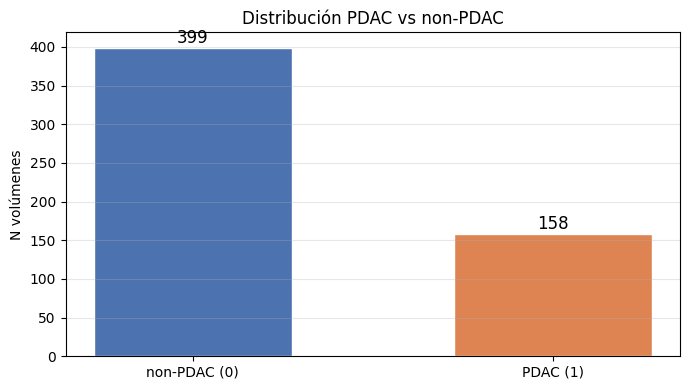

Ratio imbalance: 2.53x → Se recomienda FocalLoss


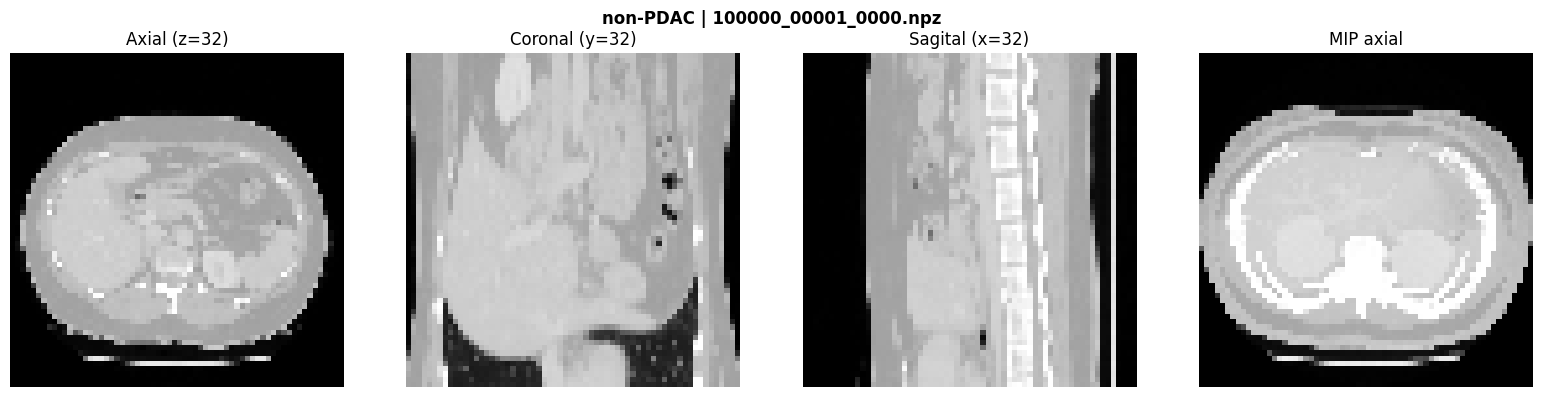

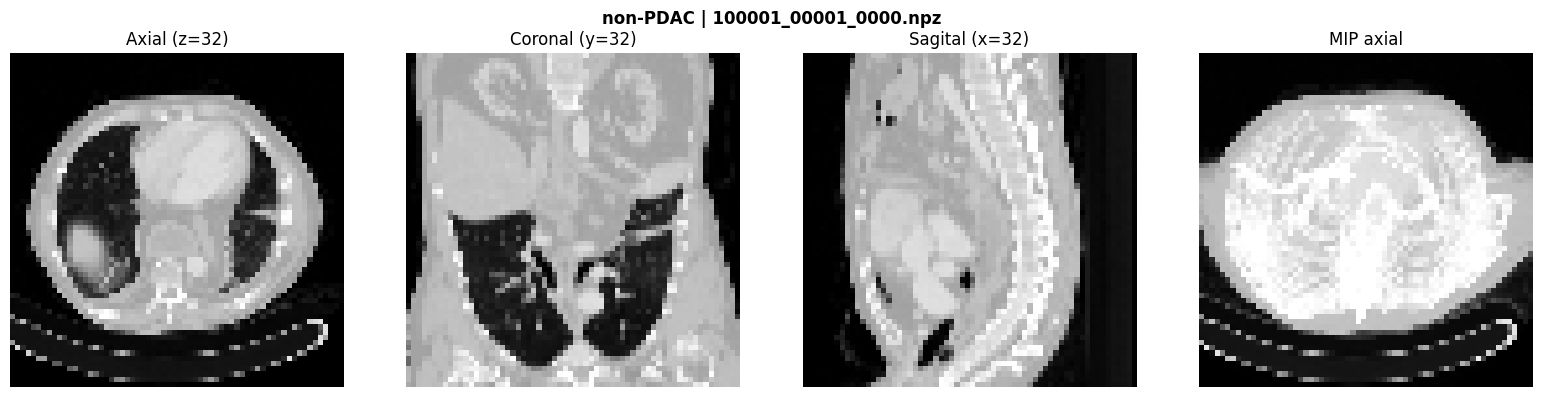

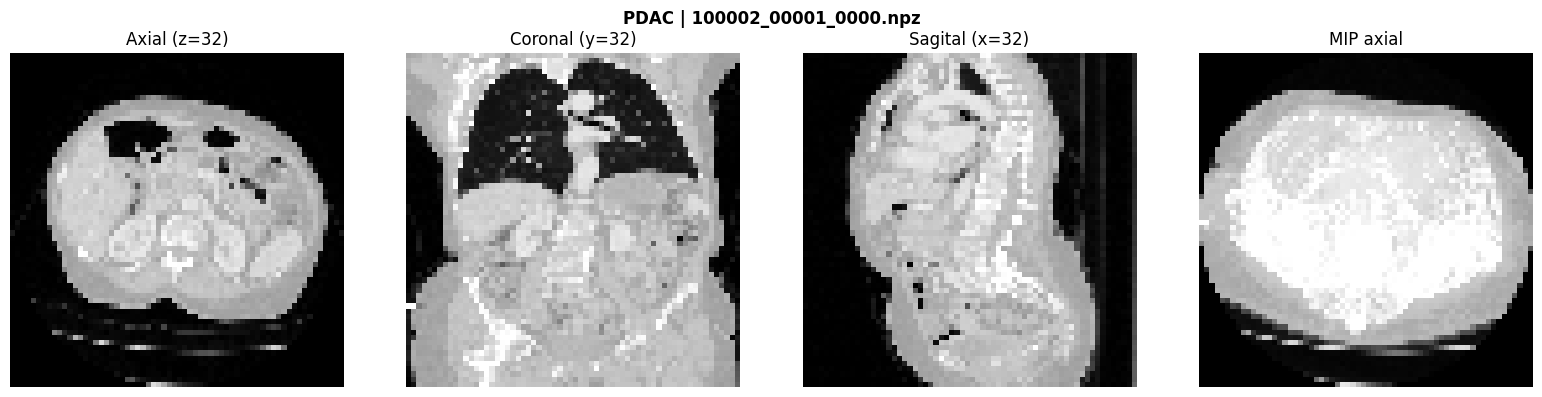

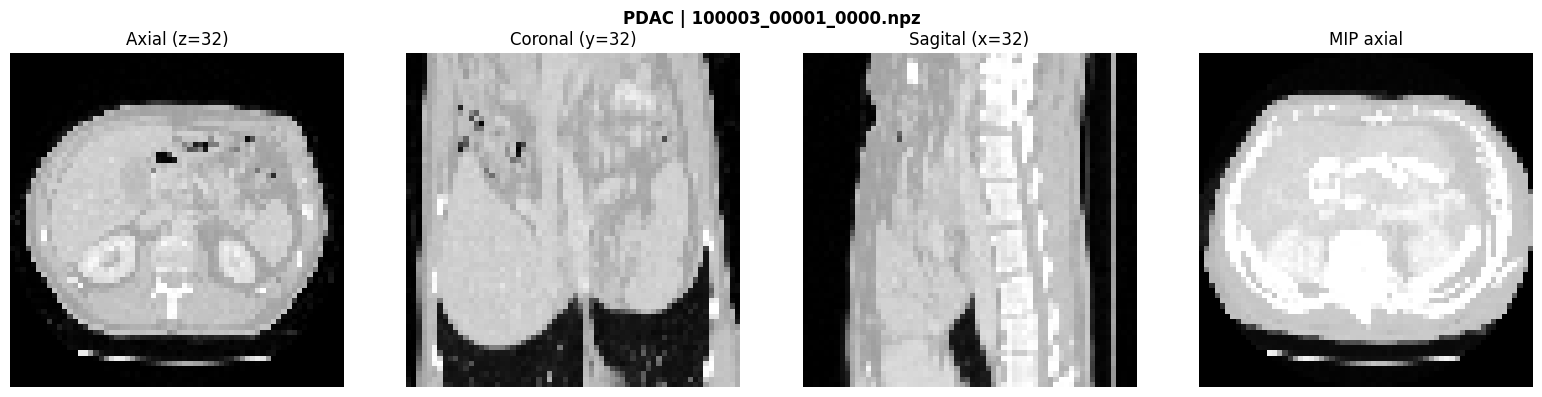

In [ ]:
# Distribución de clases
if vol_labels:
    n0 = sum(1 for v in vol_labels.values() if v == 0)
    n1 = sum(1 for v in vol_labels.values() if v == 1)
    ratio = max(n0, n1) / max(min(n0, n1), 1)
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(['non-PDAC (0)', 'PDAC (1)'], [n0, n1],
                  color=['#4c72b0','#dd8452'], edgecolor='white', width=0.55)
    for b, v in zip(bars, [n0, n1]):
        ax.text(b.get_x()+b.get_width()/2, v+1, str(v), ha='center', va='bottom', fontsize=12)
    ax.set_ylabel('N volúmenes'); ax.set_title('Distribución PDAC vs non-PDAC')
    ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()
    print(f'Ratio imbalance: {ratio:.2f}x → Se recomienda FocalLoss')
else:
    print('No hay etiquetas asignadas.')

# QA Visual 3D desde NPZ
def show_3d_slices_npz(path, title=''):
    vol = np.load(path, allow_pickle=True)['volume']
    z, y, x = vol.shape
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(vol[z//2], cmap='gray'); axes[0].set_title(f'Axial (z={z//2})')
    axes[1].imshow(vol[:, y//2, :], cmap='gray'); axes[1].set_title(f'Coronal (y={y//2})')
    axes[2].imshow(vol[:, :, x//2], cmap='gray'); axes[2].set_title(f'Sagital (x={x//2})')
    axes[3].imshow(np.max(vol, axis=0), cmap='gray'); axes[3].set_title('MIP axial')
    for a in axes: a.axis('off')
    plt.suptitle(title, fontweight='bold'); plt.tight_layout(); plt.show()

labeled_paths = list(vol_labels.keys())
for cls, name in [(0,'non-PDAC'), (1,'PDAC')]:
    paths_cls = [p for p in labeled_paths if vol_labels[p] == cls]
    for p in paths_cls[:2]:
        try:
            show_3d_slices_npz(p, f'{name} | {os.path.basename(p)}')
        except Exception as ex:
            print(f'Error visual {os.path.basename(p)}: {ex}')

## 5. Distribucion de Clases y QA Visual

Ejecutamos un **CHEQUEO EXHAUSTIVO DE INTEGRIDAD** sobre el repositorio de archivos **.npz** para garantizar que la arquitectura de datos sea óptima antes de su ingreso al modelo de aprendizaje profundo.

El despliegue técnico se estructuró bajo los siguientes puntos:

* **Validación de Estructura Volumétrica:** En esta fase se realizó un chequeo exhaustivo de todos los archivos .npz generados previamente en el proceso de conversión, con el objetivo de asegurar que cada volumen estuviera correctamente estructurado antes de ser utilizado en el modelo.
* **Verificación de Parámetros Técnicos:** Para ello, se recorrieron todos los archivos validando que cumplieran condiciones clave como **dimensiones exactas (64³)** y **tipo de dato adecuado (float32)**.
* **Control de Rango Dinámico:** Se confirmó que los volúmenes presentaran valores normalizados dentro del **rango [0,1]**, eliminando posibles discrepancias en la escala de intensidades.



**Garantía de Consistencia Operativa**
Realizamos este proceso para **GARANTIZAR CONSISTENCIA EN LA ENTRADA DEL SISTEMA**. Al asegurar que el 100% de los archivos cumplen con estos estándares técnicos, mitigamos errores de ejecución durante el entrenamiento y aseguramos que la red neuronal procese tensores con una geometría y tipado de datos uniformes.

In [ ]:
# ── La conversión NIfTI → NPZ ya se hizo en el paso de extracción streaming ──
# Esta celda verifica que todos los NPZ están bien formados.

print("Verificando integridad de archivos NPZ...")
ok, bad = 0, 0
for f in tqdm(npz_files, desc="Verificando"):
    try:
        d = np.load(f, allow_pickle=True)
        v = d['volume']
        assert v.shape == tuple(TARGET_SIZE), f"Shape incorrecto: {v.shape}"
        assert v.dtype == np.float32, f"Dtype incorrecto: {v.dtype}"
        assert 0.0 <= v.min() and v.max() <= 1.0 + 1e-6, f"Rango fuera de [0,1]: [{v.min():.4f}, {v.max():.4f}]"
        ok += 1
    except Exception as e:
        bad += 1
        print(f"  CORRUPTO: {os.path.basename(f)}: {e}")

print(f"\nVerificación: {ok} OK, {bad} corruptos de {len(npz_files)} total")

Verificando integridad de archivos NPZ...


Verificando:   0%|          | 0/557 [00:00<?, ?it/s]


Verificación: 557 OK, 0 corruptos de 557 total


## 6. Conversion NIfTI -> NPZ (resize 64x64x64)

In [ ]:
# La conversion NIfTI -> NPZ ya se hizo en el paso de extraccion streaming (Seccion 2).
# Esta celda solo verifica que el directorio NPZ este correctamente poblado.

npz_check = sorted(glob.glob(os.path.join(NPZ_DIR, '*.npz')))
print(f'Archivos NPZ disponibles: {len(npz_check)}')
if npz_check:
    sizes = [os.path.getsize(f) for f in npz_check]
    print(f'  Tamano total: {sum(sizes)/1e9:.2f} GB')
    print(f'  Tamano promedio: {np.mean(sizes)/1e3:.1f} KB')
    print(f'  Min: {min(sizes)/1e3:.1f} KB | Max: {max(sizes)/1e3:.1f} KB')


Archivos NPZ disponibles: 557
  Tamano total: 0.42 GB
  Tamano promedio: 751.7 KB
  Min: 450.7 KB | Max: 902.7 KB


## 7. EDA Post-procesamiento y Split Estratificado

Ejecutamos una **AUDITORÍA DE PARTICIÓN Y REPRODUCIBILIDAD** para asegurar que el flujo de datos hacia el modelo sea consistente, balanceado y trazable.

El despliegue técnico se estructuró bajo los siguientes puntos:

* **Filtrado y Consistencia Inicial:** En esta etapa se partió de los archivos .npz disponibles para realizar una organización estructurada de los datos, comenzando por verificar dimensiones y etiquetas asociadas a cada volumen con el fin de asegurar consistencia antes de cualquier partición; posteriormente, se filtraron únicamente aquellos casos con etiquetas válidas (0 y 1), garantizando que el modelo trabaje con información confiable.
* **División Estratificada 80/10/10:** A partir de este conjunto limpio, se aplicó una división estratificada 80/10/10, lo que significa que se separaron los datos en entrenamiento, validación y prueba manteniendo la misma proporción de clases en cada subconjunto.
* **Garantía de Reproducibilidad:** Además, se guardó esta partición en un archivo **.json** para asegurar reproducibilidad del experimento y se generaron visualizaciones que permiten confirmar que la distribución de clases se conserva correctamente en cada split.



**Prevención de Sesgos y Evaluación Justa**
Realizamos este proceso porque mantener la proporción de clases en cada partición es **CLAVE PARA EVITAR SESGOS DURANTE EL APRENDIZAJE Y LA EVALUACIÓN**. Este despliegue técnico es fundamental para evaluar el modelo de manera justa y obtener resultados más confiables, asegurando que el rendimiento reportado sea un reflejo real de la capacidad de generalización del sistema.

Total NPZ: 557
Shapes: {(64, 64, 64): 557}
Labels: {0: 399, 1: 158}
Volumenes con label valido: 557

Split estratificado:
  Train: 445 | non-PDAC: 319 | PDAC: 126
  Val: 56 | non-PDAC: 40 | PDAC: 16
  Test: 56 | non-PDAC: 40 | PDAC: 16

Split guardado en: /content/dataset_npz/split.json


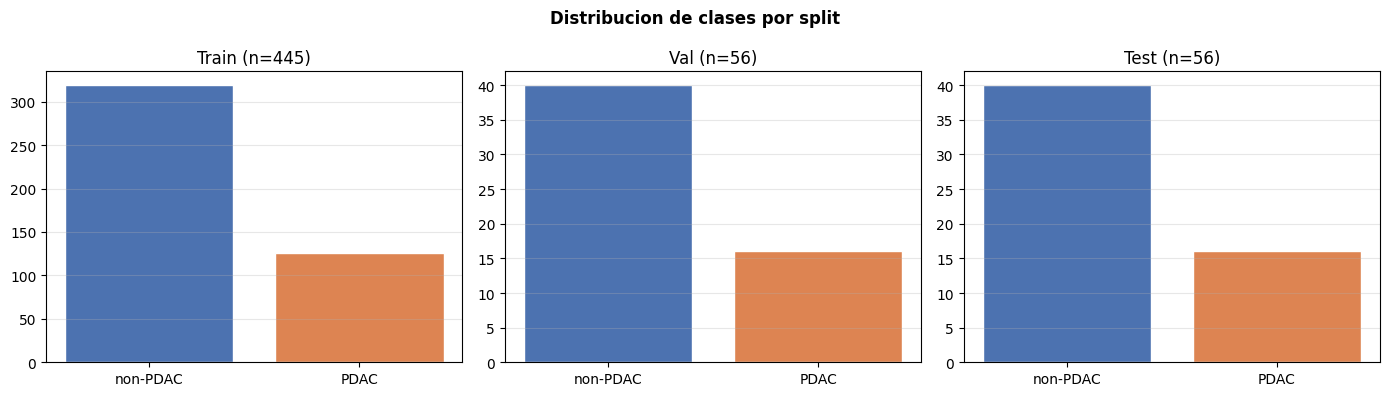

In [ ]:
from sklearn.model_selection import train_test_split

# Verificar NPZ
npz_files = sorted(glob.glob(os.path.join(NPZ_DIR, '*.npz')))
print(f'Total NPZ: {len(npz_files)}')

if npz_files:
    # Verificar shapes y labels
    shapes, labels_list, paths_list = [], [], []
    for f in npz_files:
        d = np.load(f, allow_pickle=True)
        shapes.append(d['volume'].shape)
        labels_list.append(int(d['label']))
        paths_list.append(f)
    shape_counts = Counter(shapes)
    print('Shapes:', dict(shape_counts))
    label_counts = Counter(labels_list)
    print('Labels:', dict(label_counts))

    # Filtrar solo los que tienen label valido (0 o 1)
    valid = [(p, l) for p, l in zip(paths_list, labels_list) if l in (0, 1)]
    print(f'Volumenes con label valido: {len(valid)}')

    if valid:
        vpaths, vlabels = zip(*valid)
        vpaths, vlabels = list(vpaths), list(vlabels)

        # Split 80/10/10 estratificado
        train_p, temp_p, train_l, temp_l = train_test_split(
            vpaths, vlabels, test_size=0.2, random_state=42, stratify=vlabels)
        val_p, test_p, val_l, test_l = train_test_split(
            temp_p, temp_l, test_size=0.5, random_state=42, stratify=temp_l)

        print(f'\nSplit estratificado:')
        for name, ps, ls in [('Train', train_p, train_l), ('Val', val_p, val_l), ('Test', test_p, test_l)]:
            c = Counter(ls)
            print(f'  {name}: {len(ps)} | non-PDAC: {c.get(0,0)} | PDAC: {c.get(1,0)}')

        # Guardar split
        split_path = os.path.join(NPZ_DIR, 'split.json')
        split_data = {
            'train': [os.path.basename(p) for p in train_p],
            'val':   [os.path.basename(p) for p in val_p],
            'test':  [os.path.basename(p) for p in test_p],
        }
        with open(split_path, 'w') as f:
            json.dump(split_data, f, indent=2)
        print(f'\nSplit guardado en: {split_path}')

        # Visualizar distribucion post-split
        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        for ax, (name, ls) in zip(axes, [('Train',train_l),('Val',val_l),('Test',test_l)]):
            c = Counter(ls)
            ax.bar(['non-PDAC','PDAC'], [c.get(0,0), c.get(1,0)],
                   color=['#4c72b0','#dd8452'], edgecolor='white')
            ax.set_title(f'{name} (n={len(ls)})')
            ax.grid(axis='y', alpha=0.3)
        plt.suptitle('Distribucion de clases por split', fontweight='bold')
        plt.tight_layout(); plt.show()
else:
    print('No hay archivos NPZ. Ejecuta la conversion primero.')

## 8. Pipeline MONAI (preparacion para entrenamiento)

Ejecutamos una **ORQUESTACIÓN DE DATOS Y AUMENTO SINTÉTICO** para preparar los volúmenes médicos de manera eficiente, estandarizada y robusta antes de la fase de entrenamiento.

El despliegue técnico se estructuró bajo los siguientes puntos:

* **Arquitectura de Carga Personalizada:** En esta fase se estructuró todo el flujo de carga y transformación de datos utilizando **MONAI**; inicialmente, se creó una función para organizar las rutas y etiquetas en el formato requerido, y se implementó un transform personalizado (**LoadNPZd**) que permite cargar directamente los volúmenes desde archivos **.npz**.
* **Pipelines Diferenciados de Transformación:** Se definieron dos pipelines; uno de entrenamiento con aumentos aleatorios como **flips en los tres ejes y adición de ruido gaussiano** para mejorar la capacidad de generalización del modelo, y otro más limpio para validación y prueba, evitando introducir variaciones artificiales en la evaluación.
* **Configuración de Flujo Continuo:** Posteriormente, se construyeron los **Dataset y DataLoader**, configurando el tamaño de batch y el orden de carga, lo que permite alimentar el modelo de forma continua durante el entrenamiento.



**Validación de Coherencia Operativa**
Realizamos este proceso para **ASEGURAR QUE TODO EL PIPELINE FUNCIONE DE MANERA COHERENTE**. Adicionalmente, se visualizó un batch de ejemplo para verificar que las imágenes y etiquetas se cargan correctamente, garantizando que el flujo de datos que recibe la red neuronal sea íntegro y que el aumento de datos cumpla con el objetivo de diversificar los patrones anatómicos sin corromper la señal diagnóstica.

MONAI: 1.5.2
Batch image shape: torch.Size([4, 1, 64, 64, 64])
Batch labels: tensor([1, 0, 0, 1])


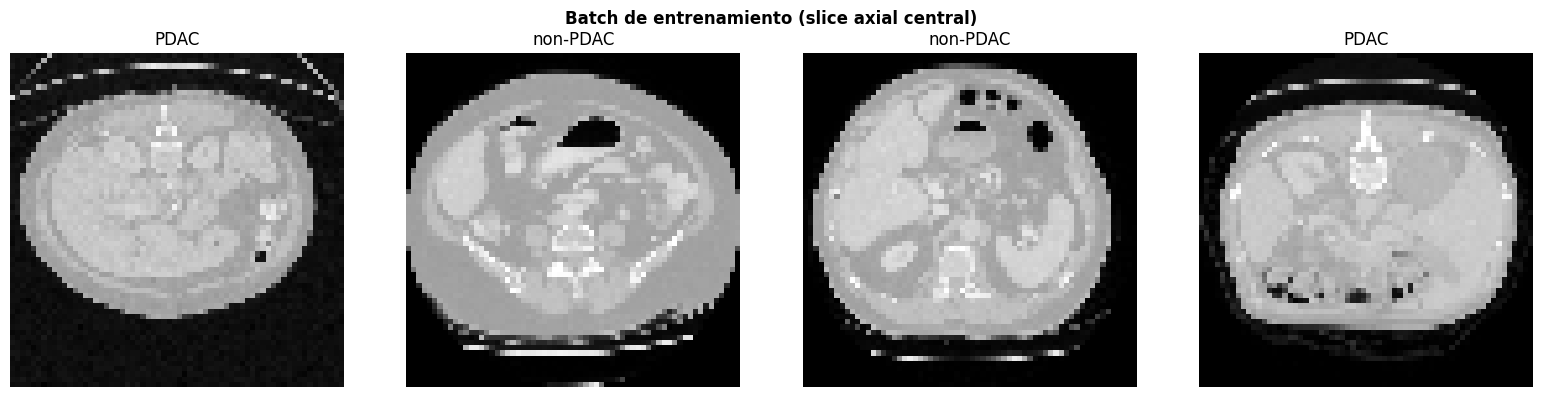


DataLoaders listos:
  Train: 445 samples, 112 batches
  Val:   56 samples, 14 batches
  Test:  56 samples, 14 batches


In [ ]:
import monai
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd,
    RandFlipd, RandAffined, RandGaussianNoised, RandAdjustContrastd,
    NormalizeIntensityd, EnsureTyped
)
from monai.data import Dataset, DataLoader
print(f'MONAI: {monai.__version__}')

# Construir lista de dicts para MONAI
def build_monai_list(paths, labels):
    return [{'image': p, 'label': l} for p, l in zip(paths, labels)]

# Custom transform para cargar NPZ
class LoadNPZd(monai.transforms.MapTransform):
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            npz = np.load(d[key], allow_pickle=True)
            d[key] = npz['volume'].astype(np.float32)
        return d

train_transforms = Compose([
    LoadNPZd(keys=['image']),
    EnsureChannelFirstd(keys=['image'], channel_dim='no_channel'),
    RandFlipd(keys=['image'], prob=0.5, spatial_axis=0),
    RandFlipd(keys=['image'], prob=0.5, spatial_axis=1),
    RandFlipd(keys=['image'], prob=0.5, spatial_axis=2),
    RandGaussianNoised(keys=['image'], prob=0.3, mean=0.0, std=0.02),
    EnsureTyped(keys=['image', 'label']),
])

val_transforms = Compose([
    LoadNPZd(keys=['image']),
    EnsureChannelFirstd(keys=['image'], channel_dim='no_channel'),
    EnsureTyped(keys=['image', 'label']),
])

if npz_files and valid:
    train_ds = Dataset(data=build_monai_list(train_p, train_l), transform=train_transforms)
    val_ds   = Dataset(data=build_monai_list(val_p, val_l),   transform=val_transforms)
    test_ds  = Dataset(data=build_monai_list(test_p, test_l), transform=val_transforms)

    train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=4, shuffle=False, num_workers=0)

    # Visualizar un batch
    batch = next(iter(train_loader))
    print(f'Batch image shape: {batch["image"].shape}')
    print(f'Batch labels: {batch["label"]}')

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for i in range(min(4, len(batch['image']))):
        vol = batch['image'][i, 0].numpy()
        axes[i].imshow(vol[vol.shape[0]//2], cmap='gray')
        lbl = 'PDAC' if batch['label'][i] == 1 else 'non-PDAC'
        axes[i].set_title(f'{lbl}'); axes[i].axis('off')
    plt.suptitle('Batch de entrenamiento (slice axial central)', fontweight='bold')
    plt.tight_layout(); plt.show()

    print(f'\nDataLoaders listos:')
    print(f'  Train: {len(train_ds)} samples, {len(train_loader)} batches')
    print(f'  Val:   {len(val_ds)} samples, {len(val_loader)} batches')
    print(f'  Test:  {len(test_ds)} samples, {len(test_loader)} batches')
else:
    print('Ejecuta las secciones anteriores primero.')

In [ ]:
import shutil
import os

FINAL_ZIP_PATH = os.path.join(_PROJ, 'dataset_npz_procesado.zip')

if ON_COLAB:
    print(f"Empaquetando archivos NPZ...")
    # Comprimir el directorio local de NPZ a tu Drive
    shutil.make_archive('/content/dataset_npz_procesado', 'zip', NPZ_DIR)

    print(f"Subiendo archivo final al Drive: {FINAL_ZIP_PATH}")
    shutil.copy2('/content/dataset_npz_procesado.zip', FINAL_ZIP_PATH)
    print("¡Guardado exitoso! Para notebook de entrenamiento, solo descomprime 'dataset_npz_procesado.zip' y salta todo este largo EDA.")
else:
    print("Estás en ejecución local. Los archivos ya están persistentes en:", NPZ_DIR)


Empaquetando archivos NPZ...
Subiendo archivo final al Drive: /content/drive/MyDrive/PROYECTO_MOE_VISION/dataset_npz_procesado.zip
¡Guardado exitoso! Para notebook de entrenamiento, solo descomprime 'dataset_npz_procesado.zip' y salta todo este largo EDA.


Ejecutamos un **ANÁLISIS DE VOLUMETRÍA PROMEDIO** para establecer una comparativa anatómica estandarizada entre grupos de estudio.

El despliegue técnico se estructuró bajo los siguientes puntos:

* **Construcción de Huella Morfológica:** En esta etapa se buscó identificar diferencias estructurales entre volúmenes con y sin presencia de cáncer, para lo cual se separaron los datos por clase y se calcularon volúmenes promedio 3D a partir de múltiples muestras, permitiendo construir una especie de “huella morfológica” representativa de cada grupo.
* **Normalización y Reducción de Ruido:** Este proceso consistió en acumular los volúmenes y normalizarlos por la cantidad de casos, generando así una imagen promedio que reduce el ruido individual y resalta patrones comunes.
* **Visualización Multiplanar Comparativa:** Posteriormente, se visualizaron cortes en los planos axial, coronal y sagital tanto para casos non-PDAC como PDAC, lo que facilita una comparación directa de posibles diferencias anatómicas relevantes.



**Identificación de Patrones Anatómicos**
Realizamos este proceso para garantizar que la red neuronal disponga de rasgos estructurales consistentes para realizar la discriminación diagnóstica. Al promediar los volúmenes, logramos resaltar las áreas de mayor relevancia morfológica entre las clases, proporcionando una base visual sólida para validar la coherencia de los datos antes del entrenamiento.

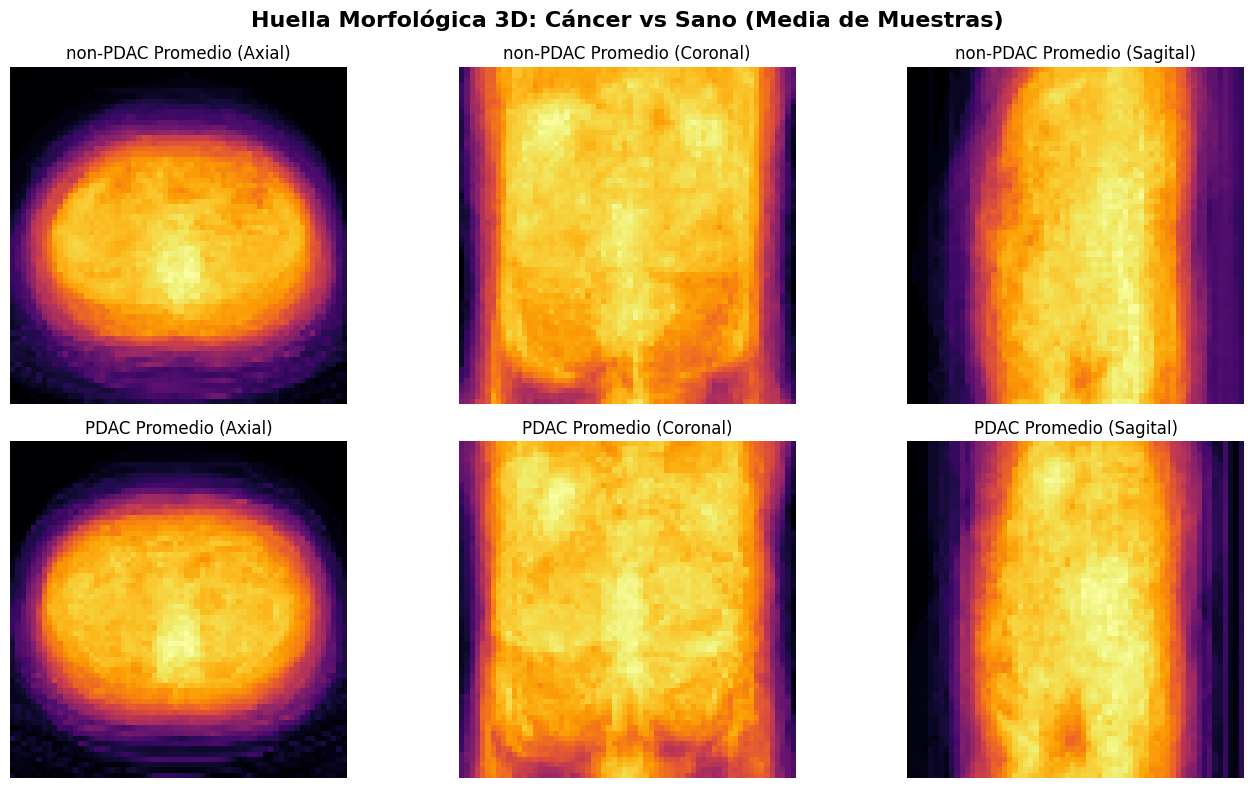

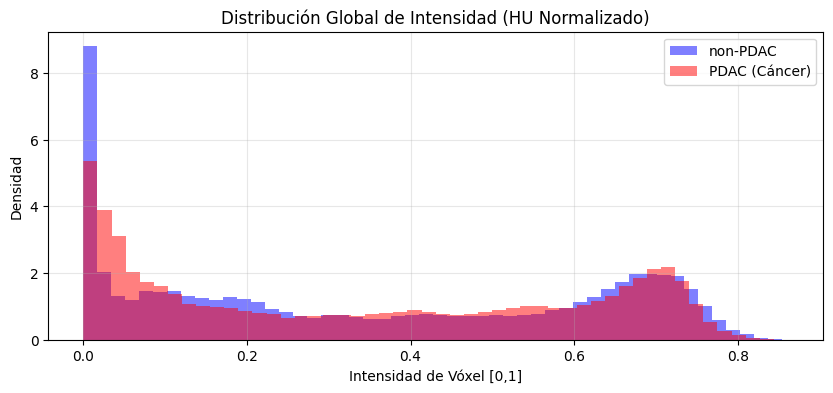

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import glob

# Recargar listas rápido en caso de no correr todo el notebook
npz_files = sorted(glob.glob(os.path.join(NPZ_DIR, '*.npz')))
labels_list = []
paths_list = []

for f in npz_files:
    d = np.load(f, allow_pickle=True)
    labels_list.append(int(d['label']))
    paths_list.append(f)

# Dividir ejemplos por clase
pdac_files = [p for p, l in zip(paths_list, labels_list) if l == 1][:30]   # Tomamos máx 30
non_pdac_files = [p for p, l in zip(paths_list, labels_list) if l == 0][:30]

def compute_mean_volume(files):
    if not files: return None
    vol_sum = np.zeros(TARGET_SIZE, dtype=np.float32)
    for f in files:
        d = np.load(f, allow_pickle=True)
        vol_sum += d['volume']
    return vol_sum / len(files)

mean_pdac = compute_mean_volume(pdac_files)
mean_non_pdac = compute_mean_volume(non_pdac_files)

if mean_pdac is not None and mean_non_pdac is not None:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))

    # Fila sanos (non-PDAC)
    z, y, x = mean_non_pdac.shape
    axes[0,0].imshow(mean_non_pdac[z//2], cmap='inferno'); axes[0,0].set_title('non-PDAC Promedio (Axial)')
    axes[0,1].imshow(mean_non_pdac[:, y//2, :], cmap='inferno'); axes[0,1].set_title('non-PDAC Promedio (Coronal)')
    axes[0,2].imshow(mean_non_pdac[:, :, x//2], cmap='inferno'); axes[0,2].set_title('non-PDAC Promedio (Sagital)')

    # Fila enfermos (PDAC)
    axes[1,0].imshow(mean_pdac[z//2], cmap='inferno'); axes[1,0].set_title('PDAC Promedio (Axial)')
    axes[1,1].imshow(mean_pdac[:, y//2, :], cmap='inferno'); axes[1,1].set_title('PDAC Promedio (Coronal)')
    axes[1,2].imshow(mean_pdac[:, :, x//2], cmap='inferno'); axes[1,2].set_title('PDAC Promedio (Sagital)')

    for ax in axes.flatten(): ax.axis('off')
    plt.suptitle('Huella Morfológica 3D: Cáncer vs Sano (Media de Muestras)', fontweight='bold', fontsize=16)
    plt.tight_layout()
    plt.show()

    # Graficar Histograma Promedio de Intensidades
    plt.figure(figsize=(10, 4))
    plt.hist(mean_non_pdac.flatten(), bins=50, alpha=0.5, label='non-PDAC', color='blue', density=True)
    plt.hist(mean_pdac.flatten(), bins=50, alpha=0.5, label='PDAC (Cáncer)', color='red', density=True)
    plt.title('Distribución Global de Intensidad (HU Normalizado)')
    plt.xlabel('Intensidad de Vóxel [0,1]')
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("Esperando a procesar más datos para generar promedios.")


## 9. Resumen y Notas para Entrenamiento

### Dataset procesado
| Propiedad | Valor |
|-----------|-------|
| Formato entrada | NIfTI (`.nii.gz`) |
| Formato salida | NPZ (`.npz`) |
| Resize | 64×64×64 |
| Ventana HU | [-1000, 400] |
| Normalizacion | [0, 1] |
| Clases | 0 = non-PDAC, 1 = PDAC |
| Imbalance | Severo → **FocalLoss** obligatorio |

### Requisitos para el modelo 3D
- **FocalLoss**: El severo imbalance entre PDAC y non-PDAC requiere FocalLoss
- **Gradient Checkpointing**: **OBLIGATORIO** para modelos 3D (reduce VRAM)
- **Modelo candidato**: Escoger el de menos parametros (R3D-18, MedicalNet, Swin3D-Tiny)
- **FP16 Mixed Precision**: Recomendado para optimizar VRAM
- **Batch size**: Ajustar segun VRAM disponible (empezar con 4)

### Unidades Hounsfield (HU) - Referencia
- Aire: -1000 HU
- Grasa: ~-50 HU
- Agua: 0 HU
- Tejido blando (pancreas normal): 30-50 HU
- Pancreas con contraste: >100 HU
- Hueso: 300-1000+ HU
- Metal (clips quirurgicos): >3000 HU (artefactos)